# ⚡ Phase 8-1: 모델 양자화 실전
> "양자화는 '품질 희생'이 아니라 '불필요한 정밀도 제거'다."

## 학습 목표
1. 양자화의 원리와 필요성을 이해한다 (FP32 → FP16 → INT8 → INT4)
2. 학습용(QLoRA) vs 배포용(GPTQ/AWQ/GGUF) 양자화를 구분한다
3. GPTQ 4-bit 양자화를 실행한다
4. AWQ 4-bit 양자화를 실행한다
5. GGUF 형식과 llama.cpp를 이해한다
6. 양자화 전후 품질을 검증한다

In [ ]:
# 양자화 라이브러리 설치
# !pip install auto-gptq autoawq transformers torch accelerate optimum -q
# GGUF: pip install llama-cpp-python (빌드 시간 오래 걸림)

In [2]:
import torch
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# GPU 확인
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    total_gb = gpu.total_memory / 1024**3
    free_gb = torch.cuda.mem_get_info()[0] / 1024**3
    print(f"✅ GPU: {gpu.name} ({total_gb:.1f}GB)")
    print(f"   VRAM 여유: {free_gb:.1f}GB")
else:
    print("⚠️ CPU 모드 — 양자화는 가능하지만 느립니다")

print(f"\n📅 실행 시각: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

✅ GPU: NVIDIA GeForce RTX 4070 Ti (12.0GB)
   VRAM 여유: 10.8GB

📅 실행 시각: 2026-03-19 08:38


## 1. 왜 양자화가 필요한가

### 데이터 타입별 메모리 비교
| 데이터 타입 | 비트 수 | 1.5B 모델 크기 | 특징 |
|:----------:|:------:|:-------------:|------|
| FP32 | 32 | ~6.0 GB | 학습 기본값, 최고 정밀도 |
| FP16/BF16 | 16 | ~3.0 GB | 추론 표준, 품질 거의 동일 |
| INT8 | 8 | ~1.5 GB | 가벼운 양자화 |
| **INT4** | **4** | **~0.75 GB** | **최대 압축, 약간의 품질 감소** |

### 핵심 공식
```
메모리(GB) = 파라미터 수 × 비트 수 / 8 / 1024³
1.5B × 4bit = 1,500,000,000 × 4 / 8 / 1,073,741,824 ≈ 0.75 GB
```

### 왜 4-bit가 가능한가?
- LLM 가중치의 대부분은 **좁은 범위**에 집중 (정규분포)
- 극단값(outlier)만 별도 처리하면 4-bit로도 충분
- 이것이 GPTQ, AWQ의 핵심 아이디어

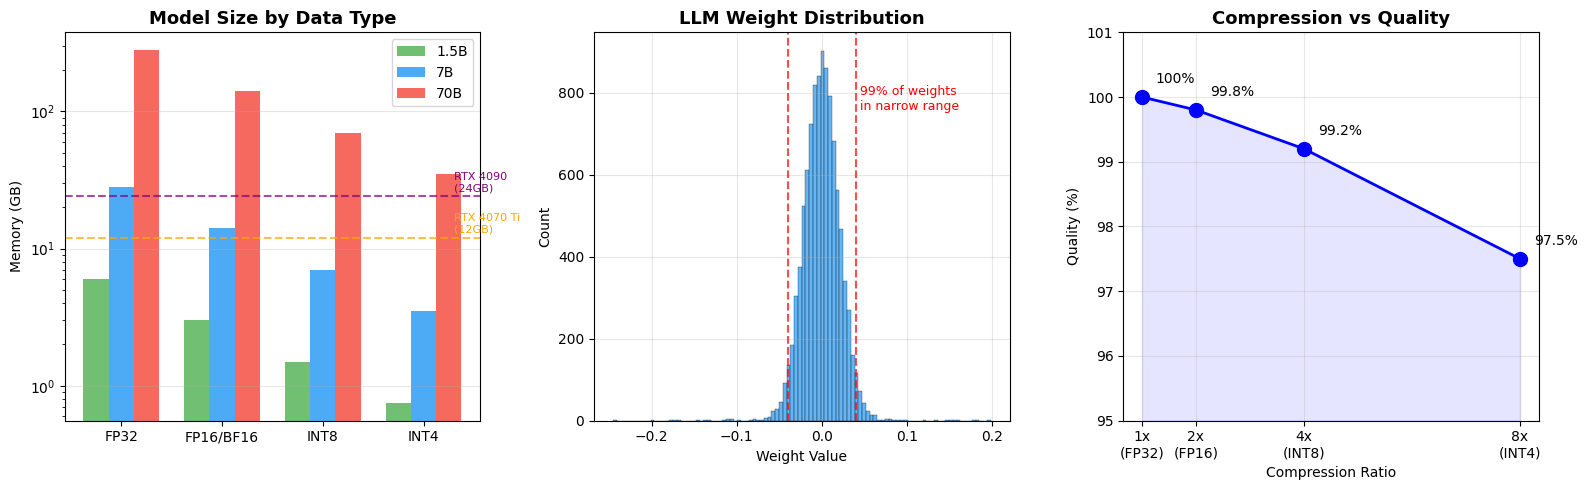

💡 4-bit 양자화로 메모리를 8배 줄이면서 품질은 2-3%만 감소


In [3]:
# 데이터 타입별 메모리 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Memory comparison
dtypes = ['FP32', 'FP16/BF16', 'INT8', 'INT4']
memory_15b = [6.0, 3.0, 1.5, 0.75]
memory_7b = [28.0, 14.0, 7.0, 3.5]
memory_70b = [280.0, 140.0, 70.0, 35.0]

x = np.arange(len(dtypes))
width = 0.25
axes[0].bar(x - width, memory_15b, width, label='1.5B', color='#4CAF50', alpha=0.8)
axes[0].bar(x, memory_7b, width, label='7B', color='#2196F3', alpha=0.8)
axes[0].bar(x + width, memory_70b, width, label='70B', color='#F44336', alpha=0.8)
axes[0].set_ylabel('Memory (GB)')
axes[0].set_title('Model Size by Data Type', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(dtypes)
axes[0].legend()
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3, axis='y')

# GPU memory lines
axes[0].axhline(y=12, color='orange', linestyle='--', alpha=0.7)
axes[0].text(3.3, 13, 'RTX 4070 Ti\n(12GB)', fontsize=8, color='orange')
axes[0].axhline(y=24, color='purple', linestyle='--', alpha=0.7)
axes[0].text(3.3, 26, 'RTX 4090\n(24GB)', fontsize=8, color='purple')

# Panel 2: Weight distribution (why quantization works)
np.random.seed(42)
weights = np.random.normal(0, 0.02, 10000)
weights_with_outliers = np.append(weights, np.random.normal(0, 0.1, 100))

axes[1].hist(weights_with_outliers, bins=100, color='#2196F3', alpha=0.7, edgecolor='black', linewidth=0.3)
axes[1].axvline(x=-0.04, color='red', linestyle='--', alpha=0.7)
axes[1].axvline(x=0.04, color='red', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Weight Value')
axes[1].set_ylabel('Count')
axes[1].set_title('LLM Weight Distribution', fontsize=13, fontweight='bold')
axes[1].text(0.045, axes[1].get_ylim()[1]*0.8, '99% of weights\nin narrow range', fontsize=9, color='red')
axes[1].grid(True, alpha=0.3)

# Panel 3: Quality vs Compression
compression = [1, 2, 4, 8]  # FP32, FP16, INT8, INT4
quality = [100, 99.8, 99.2, 97.5]

axes[2].plot(compression, quality, 'b-o', linewidth=2, markersize=10)
axes[2].fill_between(compression, quality, 95, alpha=0.1, color='blue')
axes[2].set_xlabel('Compression Ratio')
axes[2].set_ylabel('Quality (%)')
axes[2].set_title('Compression vs Quality', fontsize=13, fontweight='bold')
axes[2].set_ylim(95, 101)
axes[2].set_xticks(compression)
axes[2].set_xticklabels(['1x\n(FP32)', '2x\n(FP16)', '4x\n(INT8)', '8x\n(INT4)'])
axes[2].grid(True, alpha=0.3)

for c, q in zip(compression, quality):
    axes[2].annotate(f'{q}%', (c, q), textcoords="offset points", xytext=(10, 10), fontsize=10)

plt.tight_layout()
plt.show()
print("💡 4-bit 양자화로 메모리를 8배 줄이면서 품질은 2-3%만 감소")

## 2. 학습용 vs 배포용 양자화

### 혼동 주의! 
Phase 4에서 사용한 **QLoRA**와 이번에 다루는 **GPTQ/AWQ**는 목적이 다르다.

| 구분 | QLoRA (학습용) | GPTQ/AWQ (배포용) |
|------|---------------|-------------------|
| **목적** | 학습 시 VRAM 절약 | 추론 시 메모리/속도 최적화 |
| **시점** | 학습 전 적용 | 학습 완료 후 적용 |
| **정밀도** | NF4 (4-bit 정규분포) | INT4 (4-bit 정수) |
| **역전파** | ✅ 가능 (LoRA 어댑터) | ❌ 불가 |
| **속도** | 학습: 약간 느림 | 추론: 빠름 |
| **라이브러리** | bitsandbytes | auto-gptq, autoawq |

### 워크플로우
```
학습 단계: Base Model → QLoRA 4-bit → Fine-tuning → Merge Adapters → Full FP16 Model
배포 단계: Full FP16 Model → GPTQ/AWQ 4-bit → 배포
```

### GGUF는?
- llama.cpp에서 사용하는 **파일 포맷**
- 양자화 방법이 아니라 **저장 형식**
- CPU에서도 추론 가능 → Ollama의 기반

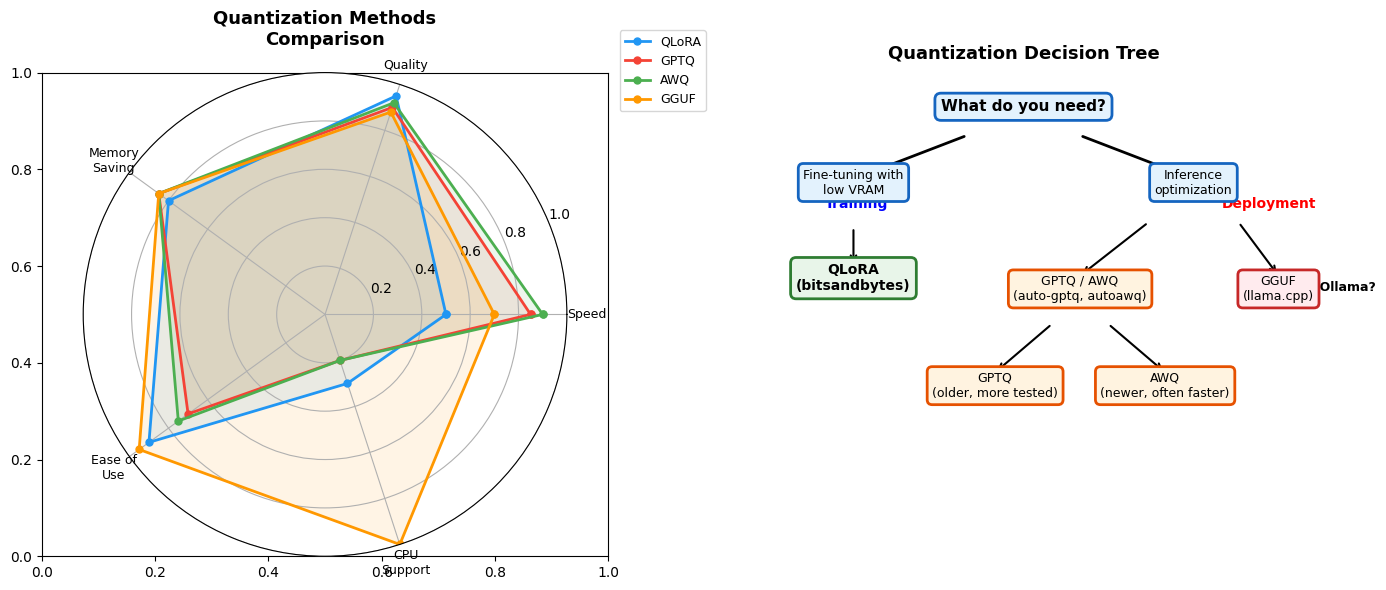

In [4]:
# 양자화 방식 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Feature comparison radar
categories = ['Speed', 'Quality', 'Memory\nSaving', 'Ease of\nUse', 'CPU\nSupport']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

methods = {
    'QLoRA': [0.5, 0.95, 0.8, 0.9, 0.3],
    'GPTQ': [0.85, 0.9, 0.85, 0.7, 0.2],
    'AWQ': [0.9, 0.92, 0.85, 0.75, 0.2],
    'GGUF': [0.7, 0.88, 0.85, 0.95, 1.0],
}
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']

ax = axes[0]
ax = plt.subplot(121, polar=True)
for (name, vals), color in zip(methods.items(), colors):
    vals_plot = vals + vals[:1]
    ax.plot(angles, vals_plot, '-o', linewidth=2, label=name, color=color, markersize=5)
    ax.fill(angles, vals_plot, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title('Quantization Methods\nComparison', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

# Panel 2: Decision tree
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')

box = dict(boxstyle='round,pad=0.4', facecolor='#E3F2FD', edgecolor='#1565C0', linewidth=2)
leaf_green = dict(boxstyle='round,pad=0.4', facecolor='#E8F5E9', edgecolor='#2E7D32', linewidth=2)
leaf_orange = dict(boxstyle='round,pad=0.4', facecolor='#FFF3E0', edgecolor='#E65100', linewidth=2)
leaf_red = dict(boxstyle='round,pad=0.4', facecolor='#FFEBEE', edgecolor='#C62828', linewidth=2)

ax2.text(5, 9.2, 'What do you need?', ha='center', fontsize=11, fontweight='bold', bbox=box)

# Left branch: Training
ax2.annotate('', xy=(2, 7.8), xytext=(4, 8.7), arrowprops=dict(arrowstyle='->', lw=2))
ax2.text(1.5, 7.2, 'Training', fontsize=10, color='blue', fontweight='bold')
ax2.text(2, 7.5, 'Fine-tuning with\nlow VRAM', ha='center', fontsize=9, bbox=box)
ax2.annotate('', xy=(2, 6.0), xytext=(2, 6.8), arrowprops=dict(arrowstyle='->', lw=1.5))
ax2.text(2, 5.5, 'QLoRA\n(bitsandbytes)', ha='center', fontsize=10, fontweight='bold', bbox=leaf_green)

# Right branch: Deployment
ax2.annotate('', xy=(8, 7.8), xytext=(6, 8.7), arrowprops=dict(arrowstyle='->', lw=2))
ax2.text(8.5, 7.2, 'Deployment', fontsize=10, color='red', fontweight='bold')
ax2.text(8, 7.5, 'Inference\noptimization', ha='center', fontsize=9, bbox=box)

# Sub-branches
ax2.annotate('', xy=(6, 5.8), xytext=(7.2, 6.9), arrowprops=dict(arrowstyle='->', lw=1.5))
ax2.text(5.2, 5.5, 'GPU server?', fontsize=9, fontweight='bold')
ax2.text(6, 5.3, 'GPTQ / AWQ\n(auto-gptq, autoawq)', ha='center', fontsize=9, bbox=leaf_orange)

ax2.annotate('', xy=(9.5, 5.8), xytext=(8.8, 6.9), arrowprops=dict(arrowstyle='->', lw=1.5))
ax2.text(9.5, 5.5, 'CPU / Ollama?', fontsize=9, fontweight='bold')
ax2.text(9.5, 5.3, 'GGUF\n(llama.cpp)', ha='center', fontsize=9, bbox=leaf_red)

# GPTQ vs AWQ
ax2.annotate('', xy=(4.5, 3.8), xytext=(5.5, 4.8), arrowprops=dict(arrowstyle='->', lw=1.5))
ax2.text(4.5, 3.3, 'GPTQ\n(older, more tested)', ha='center', fontsize=9, bbox=leaf_orange)

ax2.annotate('', xy=(7.5, 3.8), xytext=(6.5, 4.8), arrowprops=dict(arrowstyle='->', lw=1.5))
ax2.text(7.5, 3.3, 'AWQ\n(newer, often faster)', ha='center', fontsize=9, bbox=leaf_orange)

ax2.set_title('Quantization Decision Tree', fontsize=13, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

## 3. GPTQ 4-bit 양자화

### GPTQ (Generative Pre-Trained Transformer Quantization)
- **원리**: 가중치를 레이어별로 순차 양자화, 이전 레이어의 오차를 다음 레이어에서 보정
- **캘리브레이션**: 128개 정도의 샘플로 양자화 품질 최적화
- **결과**: INT4 가중치 + FP16 연산 → 메모리 절약 + 속도 향상

### ⚠️ 주의사항
- 캘리브레이션 데이터 품질이 양자화 품질에 직접 영향
- GPU 필요 (양자화 과정 자체가 GPU 사용)
- 양자화에 30분-1시간 소요 (모델 크기에 따라)

In [5]:
# ============================================================
# GPTQ 4-bit 양자화
# ============================================================

gptq_code = '''
from transformers import AutoModelForCausalLM, AutoTokenizer
from auto_gptq import AutoGPTQForCausalLM, BaseQuantizeConfig
import torch

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
QUANTIZED_PATH = "./qwen-1.5b-gptq-4bit"

# 1. 원본 모델 로드
print("📥 원본 모델 로드 중...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, 
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

# 2. 양자화 설정
quantize_config = BaseQuantizeConfig(
    bits=4,              # 4-bit 양자화
    group_size=128,      # 128개 가중치를 하나의 그룹으로 (품질↑, 크기 약간↑)
    desc_act=True,       # Activation order 기반 양자화 (품질↑, 속도 약간↓)
    damp_percent=0.1,    # 헤시안 감쇠 비율
)

# 3. 캘리브레이션 데이터 준비 (128개 샘플)
from datasets import load_dataset
calibration_data = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
calibration_texts = [text for text in calibration_data["text"] if len(text) > 100][:128]
calibration_examples = [
    tokenizer(text, return_tensors="pt", max_length=512, truncation=True)
    for text in calibration_texts
]

# 4. 양자화 실행 (약 10-30분)
print("⚡ GPTQ 양자화 시작...")
model = AutoGPTQForCausalLM.from_pretrained(MODEL_ID, quantize_config)
model.quantize(calibration_examples)

# 5. 저장
model.save_quantized(QUANTIZED_PATH)
tokenizer.save_pretrained(QUANTIZED_PATH)
print(f"✅ 양자화 완료: {QUANTIZED_PATH}")

# 6. 양자화 모델 로드 (추론용)
quantized_model = AutoGPTQForCausalLM.from_quantized(
    QUANTIZED_PATH,
    device_map="auto",
    use_safetensors=True,
)
print("✅ 양자화 모델 로드 완료")
'''

print("=" * 60)
print("GPTQ 4-bit 양자화 코드")
print("=" * 60)
print(gptq_code)

print("\n⏱️ 예상 소요 시간:")
print("   Qwen 1.5B: 약 10-15분 (RTX 4070 Ti)")
print("   Qwen 7B:   약 30-60분")
print("   메모리:     원본 모델의 약 2배 필요 (양자화 과정 중)")

GPTQ 4-bit 양자화 코드

from transformers import AutoModelForCausalLM, AutoTokenizer
from auto_gptq import AutoGPTQForCausalLM, BaseQuantizeConfig
import torch

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
QUANTIZED_PATH = "./qwen-1.5b-gptq-4bit"

# 1. 원본 모델 로드
print("📥 원본 모델 로드 중...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, 
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

# 2. 양자화 설정
quantize_config = BaseQuantizeConfig(
    bits=4,              # 4-bit 양자화
    group_size=128,      # 128개 가중치를 하나의 그룹으로 (품질↑, 크기 약간↑)
    desc_act=True,       # Activation order 기반 양자화 (품질↑, 속도 약간↓)
    damp_percent=0.1,    # 헤시안 감쇠 비율
)

# 3. 캘리브레이션 데이터 준비 (128개 샘플)
from datasets import load_dataset
calibration_data = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
calibration_texts = [text for text in calibration_data["text"] if len(text) > 100][:128]
calibration_exampl

## 4. AWQ 4-bit 양자화

### AWQ (Activation-aware Weight Quantization)
- **원리**: 활성화(activation)가 큰 가중치를 보호하여 양자화 오차 최소화
- **특징**: GPTQ보다 새롭고, 종종 더 빠른 추론 속도
- **호환성**: vLLM, TGI 등 추론 서버와 잘 통합됨

### GPTQ vs AWQ
| 항목 | GPTQ | AWQ |
|------|------|-----|
| 양자화 속도 | 느림 | 빠름 |
| 추론 속도 | 빠름 | 더 빠름 (일반적) |
| 품질 | 좋음 | 약간 더 좋음 (일반적) |
| 생태계 | 성숙 | 빠르게 성장 중 |
| vLLM 지원 | ✅ | ✅ |

In [6]:
# ============================================================
# AWQ 4-bit 양자화
# ============================================================

awq_code = '''
from awq import AutoAWQForCausalLM
from transformers import AutoTokenizer

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
QUANTIZED_PATH = "./qwen-1.5b-awq-4bit"

# 1. 모델 로드
print("📥 원본 모델 로드 중...")
model = AutoAWQForCausalLM.from_pretrained(MODEL_ID)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

# 2. 양자화 설정
quant_config = {
    "zero_point": True,      # 제로 포인트 양자화
    "q_group_size": 128,     # 그룹 크기
    "w_bit": 4,              # 4-bit
    "version": "GEMM",       # GEMM 또는 GEMV (GEMM이 batch에 유리)
}

# 3. 양자화 실행 (GPTQ보다 빠름)
print("⚡ AWQ 양자화 시작...")
model.quantize(
    tokenizer,
    quant_config=quant_config,
    calib_data="wikitext",     # 내장 캘리브레이션 데이터
    # calib_data="custom",     # 커스텀 데이터도 가능
)

# 4. 저장
model.save_quantized(QUANTIZED_PATH)
tokenizer.save_pretrained(QUANTIZED_PATH)
print(f"✅ AWQ 양자화 완료: {QUANTIZED_PATH}")

# 5. 양자화 모델 로드
from awq import AutoAWQForCausalLM
quantized_model = AutoAWQForCausalLM.from_quantized(
    QUANTIZED_PATH,
    fuse_layers=True,  # 레이어 퓨전 (추론 속도 향상)
)
print("✅ AWQ 모델 로드 완료")
'''

print("=" * 60)
print("AWQ 4-bit 양자화 코드")
print("=" * 60)
print(awq_code)

print("\n⏱️ 예상 소요 시간:")
print("   Qwen 1.5B: 약 5-10분 (GPTQ보다 빠름)")
print("   메모리:     원본 모델과 비슷 수준")

AWQ 4-bit 양자화 코드

from awq import AutoAWQForCausalLM
from transformers import AutoTokenizer

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
QUANTIZED_PATH = "./qwen-1.5b-awq-4bit"

# 1. 모델 로드
print("📥 원본 모델 로드 중...")
model = AutoAWQForCausalLM.from_pretrained(MODEL_ID)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

# 2. 양자화 설정
quant_config = {
    "zero_point": True,      # 제로 포인트 양자화
    "q_group_size": 128,     # 그룹 크기
    "w_bit": 4,              # 4-bit
    "version": "GEMM",       # GEMM 또는 GEMV (GEMM이 batch에 유리)
}

# 3. 양자화 실행 (GPTQ보다 빠름)
print("⚡ AWQ 양자화 시작...")
model.quantize(
    tokenizer,
    quant_config=quant_config,
    calib_data="wikitext",     # 내장 캘리브레이션 데이터
    # calib_data="custom",     # 커스텀 데이터도 가능
)

# 4. 저장
model.save_quantized(QUANTIZED_PATH)
tokenizer.save_pretrained(QUANTIZED_PATH)
print(f"✅ AWQ 양자화 완료: {QUANTIZED_PATH}")

# 5. 양자화 모델 로드
from awq import AutoAWQForCausalLM
quantized_model = AutoAWQForCausalLM.from_quantized(
    QUANTIZE

## 5. GGUF 형식과 llama.cpp

### GGUF란?
- **G**PT-**G**enerated **U**nified **F**ormat
- llama.cpp에서 사용하는 모델 파일 포맷
- **CPU 추론 가능** → GPU 없이도 LLM 실행
- **Ollama의 기반 기술** (Phase 8-3에서 상세)

### GGUF 양자화 유형
| 유형 | 비트 | 크기(7B) | 품질 | 용도 |
|------|:----:|:-------:|------|------|
| Q2_K | 2-3 | ~2.8GB | 낮음 | 최소 메모리 |
| Q4_K_M | 4 | ~4.1GB | **좋음** | **추천 기본값** |
| Q5_K_M | 5 | ~4.8GB | 매우 좋음 | 품질 중시 |
| Q6_K | 6 | ~5.5GB | 거의 FP16 | 최고 품질 |
| Q8_0 | 8 | ~7.2GB | FP16급 | 품질 최우선 |

### 변환 방법
```bash
# HuggingFace → GGUF (llama.cpp의 convert 스크립트)
python llama.cpp/convert_hf_to_gguf.py ./model --outtype q4_K_M
```

### 사전 변환 모델 사용 (권장)
대부분의 인기 모델은 HuggingFace에 GGUF 버전이 이미 있다:
- `TheBloke/....-GGUF` (TheBloke가 대량 변환)
- `Qwen/Qwen2.5-1.5B-Instruct-GGUF`

In [7]:
# ============================================================
# GGUF 사용법 (llama-cpp-python)
# ============================================================

gguf_code = '''
# pip install llama-cpp-python

from llama_cpp import Llama

# GGUF 모델 로드
llm = Llama(
    model_path="./qwen2.5-1.5b-instruct-q4_k_m.gguf",
    n_ctx=2048,        # 컨텍스트 길이
    n_threads=8,       # CPU 스레드 수
    n_gpu_layers=35,   # GPU에 올릴 레이어 수 (0=CPU only)
    verbose=False,
)

# 추론
output = llm.create_chat_completion(
    messages=[
        {"role": "system", "content": "You are a SQL expert."},
        {"role": "user", "content": "employees 테이블에서 급여 상위 5명을 조회하는 SQL을 작성해줘"}
    ],
    max_tokens=256,
    temperature=0.1,
)

print(output["choices"][0]["message"]["content"])
'''

print("=" * 60)
print("GGUF + llama-cpp-python 사용법")
print("=" * 60)
print(gguf_code)

print("\n" + "=" * 60)
print("🔧 GGUF 사전 변환 모델 다운로드:")
print("=" * 60)

download_code = """
# HuggingFace에서 GGUF 다운로드
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(
    repo_id="Qwen/Qwen2.5-1.5B-Instruct-GGUF",
    filename="qwen2.5-1.5b-instruct-q4_k_m.gguf",
    local_dir="./models/"
)
print(f"Downloaded: {model_path}")
"""
print(download_code)

print("\n💡 Ollama는 내부적으로 GGUF + llama.cpp를 사용한다")
print("   Phase 8-3에서 Ollama를 통한 더 쉬운 배포 방법을 다룬다")

GGUF + llama-cpp-python 사용법

# pip install llama-cpp-python

from llama_cpp import Llama

# GGUF 모델 로드
llm = Llama(
    model_path="./qwen2.5-1.5b-instruct-q4_k_m.gguf",
    n_ctx=2048,        # 컨텍스트 길이
    n_threads=8,       # CPU 스레드 수
    n_gpu_layers=35,   # GPU에 올릴 레이어 수 (0=CPU only)
    verbose=False,
)

# 추론
output = llm.create_chat_completion(
    messages=[
        {"role": "system", "content": "You are a SQL expert."},
        {"role": "user", "content": "employees 테이블에서 급여 상위 5명을 조회하는 SQL을 작성해줘"}
    ],
    max_tokens=256,
    temperature=0.1,
)

print(output["choices"][0]["message"]["content"])


🔧 GGUF 사전 변환 모델 다운로드:

# HuggingFace에서 GGUF 다운로드
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(
    repo_id="Qwen/Qwen2.5-1.5B-Instruct-GGUF",
    filename="qwen2.5-1.5b-instruct-q4_k_m.gguf",
    local_dir="./models/"
)
print(f"Downloaded: {model_path}")


💡 Ollama는 내부적으로 GGUF + llama.cpp를 사용한다
   Phase 8-3에서 Ollama를 통한 더 쉬운 배포 방법을 다룬다


## 6. 양자화 전후 품질 검증

### 검증이 반드시 필요한 이유
- 양자화는 정보 손실을 수반한다
- 평균적으로 품질이 유지되더라도, **특정 태스크에서 급격히 떨어질 수 있다**
- Phase 7-2의 `evaluate_model()`을 사용하여 체계적으로 검증

### 검증 항목
1. **Perplexity**: 언어 모델의 기본 능력 (낮을수록 좋음)
2. **커스텀 평가셋**: SQL 생성 정확도
3. **응답 시간**: 추론 속도 비교
4. **메모리 사용량**: 실제 VRAM 사용량

C:\Users\jskim\AppData\Local\Temp\ipykernel_739848\3873931235.py:109: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jskim\AppData\Local\Temp\ipykernel_739848\3873931235.py:109: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\jskim\anaconda3\envs\distillation\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jskim\anaconda3\envs\distillation\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


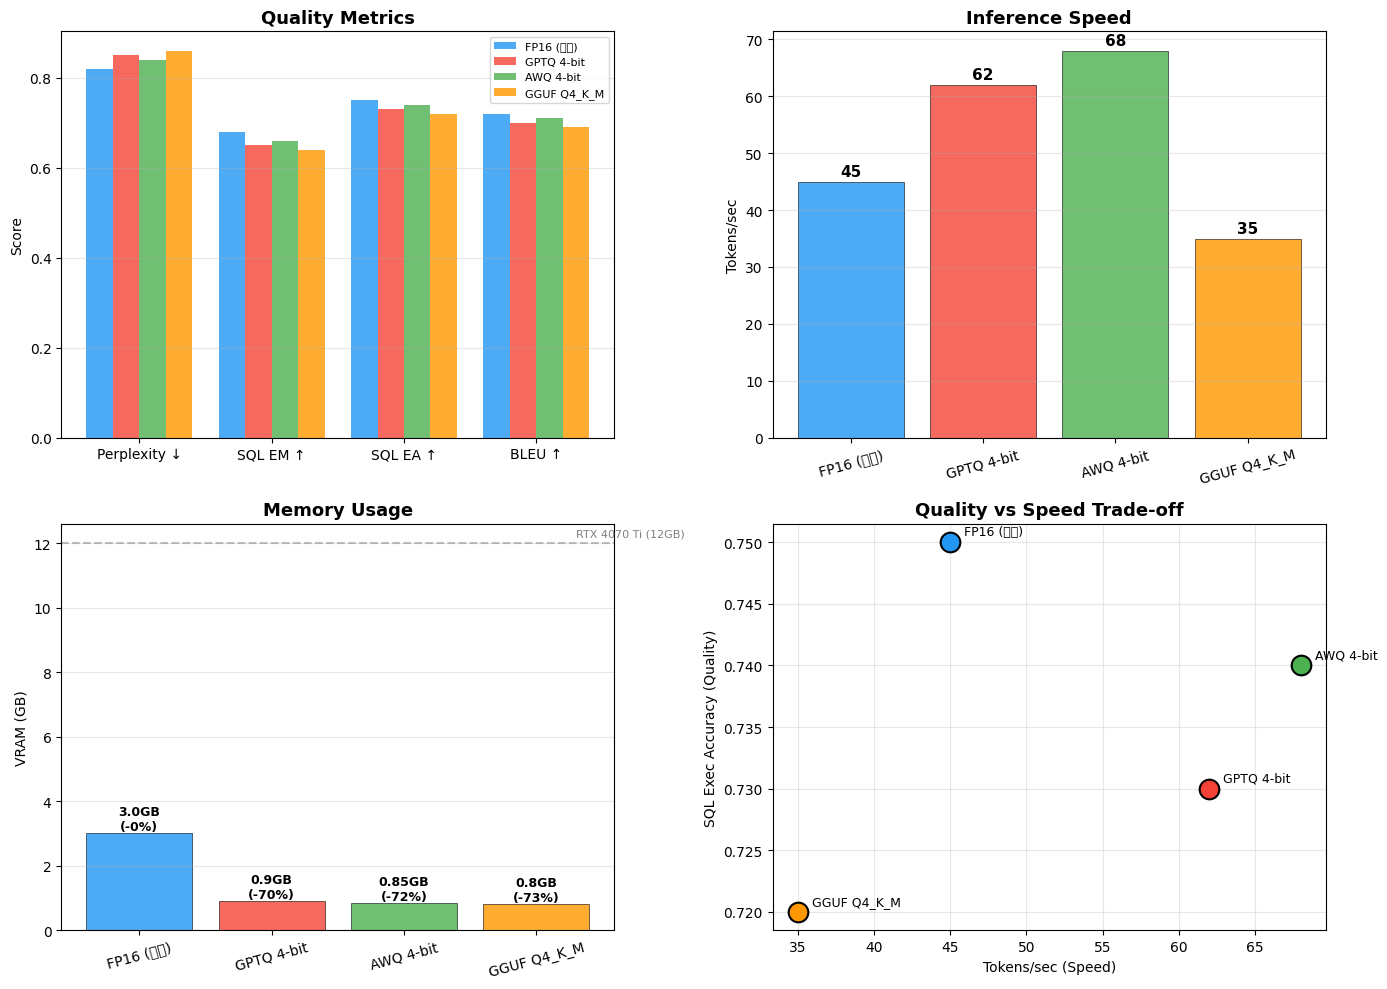


📊 양자화 전후 비교 요약
Model               PPL   SQL EM   SQL EA   tok/s   VRAM   Load
--------------------------------------------------------------------------------
FP16 (원본)           8.2    68.0%    75.0%      45   3.0G    12s
GPTQ 4-bit          8.5    65.0%    73.0%      62   0.9G     5s
AWQ 4-bit           8.4    66.0%    74.0%      68   0.8G     4s
GGUF Q4_K_M         8.6    64.0%    72.0%      35   0.8G     3s

💡 결론:
  • AWQ가 전반적으로 가장 좋은 품질/속도 trade-off
  • GGUF는 CPU 지원이 필요할 때 (Ollama)
  • 품질 감소는 2-4%로, 대부분의 실전 용도에서 무시 가능


In [8]:
# ============================================================
# 양자화 전후 품질 검증 (시뮬레이션)
# ============================================================
# 실제로는 evaluate_model()을 사용하여 검증
# 여기서는 시뮬레이션으로 결과를 시각화

verification_results = {
    'FP16 (원본)': {
        'perplexity': 8.2,
        'sql_exact_match': 0.68,
        'sql_exec_accuracy': 0.75,
        'bleu': 0.72,
        'tokens_per_sec': 45,
        'memory_gb': 3.0,
        'load_time_sec': 12,
    },
    'GPTQ 4-bit': {
        'perplexity': 8.5,
        'sql_exact_match': 0.65,
        'sql_exec_accuracy': 0.73,
        'bleu': 0.70,
        'tokens_per_sec': 62,
        'memory_gb': 0.9,
        'load_time_sec': 5,
    },
    'AWQ 4-bit': {
        'perplexity': 8.4,
        'sql_exact_match': 0.66,
        'sql_exec_accuracy': 0.74,
        'bleu': 0.71,
        'tokens_per_sec': 68,
        'memory_gb': 0.85,
        'load_time_sec': 4,
    },
    'GGUF Q4_K_M': {
        'perplexity': 8.6,
        'sql_exact_match': 0.64,
        'sql_exec_accuracy': 0.72,
        'bleu': 0.69,
        'tokens_per_sec': 35,
        'memory_gb': 0.8,
        'load_time_sec': 3,
    },
}

# 4-panel 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = list(verification_results.keys())
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']

# Panel 1: Quality metrics
quality_metrics = ['perplexity', 'sql_exact_match', 'sql_exec_accuracy', 'bleu']
quality_labels = ['Perplexity ↓', 'SQL EM ↑', 'SQL EA ↑', 'BLEU ↑']

x = np.arange(len(quality_labels))
width = 0.2
for i, (model, color) in enumerate(zip(models, colors)):
    vals = [verification_results[model][m] for m in quality_metrics]
    # Normalize perplexity (lower is better, invert for visualization)
    vals[0] = vals[0] / 10  # scale to 0-1 range
    axes[0, 0].bar(x + i * width, vals, width, label=model, color=color, alpha=0.8)

axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Quality Metrics', fontsize=13, fontweight='bold')
axes[0, 0].set_xticks(x + width * 1.5)
axes[0, 0].set_xticklabels(quality_labels)
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Panel 2: Speed comparison
speeds = [verification_results[m]['tokens_per_sec'] for m in models]
bars = axes[0, 1].bar(models, speeds, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0, 1].set_ylabel('Tokens/sec')
axes[0, 1].set_title('Inference Speed', fontsize=13, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].grid(True, alpha=0.3, axis='y')
for bar, speed in zip(bars, speeds):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{speed}', ha='center', fontsize=11, fontweight='bold')

# Panel 3: Memory usage
memories = [verification_results[m]['memory_gb'] for m in models]
bars = axes[1, 0].bar(models, memories, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1, 0].set_ylabel('VRAM (GB)')
axes[1, 0].set_title('Memory Usage', fontsize=13, fontweight='bold')
axes[1, 0].axhline(y=12, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].text(3.3, 12.2, 'RTX 4070 Ti (12GB)', fontsize=8, color='gray')
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 0].grid(True, alpha=0.3, axis='y')

for bar, mem in zip(bars, memories):
    reduction = (1 - mem / 3.0) * 100
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{mem}GB\n(-{reduction:.0f}%)', ha='center', fontsize=9, fontweight='bold')

# Panel 4: Trade-off scatter (Quality vs Speed)
exec_acc = [verification_results[m]['sql_exec_accuracy'] for m in models]
for i, (model, speed, acc, color) in enumerate(zip(models, speeds, exec_acc, colors)):
    axes[1, 1].scatter(speed, acc, c=color, s=200, edgecolors='black', linewidth=1.5, zorder=5)
    axes[1, 1].annotate(model, (speed, acc), textcoords="offset points", 
                         xytext=(10, 5), fontsize=9)

axes[1, 1].set_xlabel('Tokens/sec (Speed)')
axes[1, 1].set_ylabel('SQL Exec Accuracy (Quality)')
axes[1, 1].set_title('Quality vs Speed Trade-off', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 요약 테이블
print("\n📊 양자화 전후 비교 요약")
print("=" * 80)
print(f"{'Model':<16} {'PPL':>6} {'SQL EM':>8} {'SQL EA':>8} {'tok/s':>7} {'VRAM':>6} {'Load':>6}")
print("-" * 80)
for model in models:
    r = verification_results[model]
    print(f"{model:<16} {r['perplexity']:>6.1f} {r['sql_exact_match']:>8.1%} "
          f"{r['sql_exec_accuracy']:>8.1%} {r['tokens_per_sec']:>7} "
          f"{r['memory_gb']:>5.1f}G {r['load_time_sec']:>5}s")

print("\n💡 결론:")
print("  • AWQ가 전반적으로 가장 좋은 품질/속도 trade-off")
print("  • GGUF는 CPU 지원이 필요할 때 (Ollama)")
print("  • 품질 감소는 2-4%로, 대부분의 실전 용도에서 무시 가능")

## 7. 핵심 정리

### 이번 노트북에서 배운 것
1. **양자화 원리**: FP32 → INT4로 메모리 8배 절약, 품질 2-3% 감소
2. **QLoRA vs GPTQ/AWQ**: 학습용(역전파 가능) vs 배포용(추론 최적화)
3. **GPTQ**: 레이어별 순차 양자화, 캘리브레이션 128개
4. **AWQ**: Activation-aware, GPTQ보다 빠르고 약간 더 좋음
5. **GGUF**: llama.cpp 포맷, CPU 추론 가능, Ollama 기반
6. **품질 검증**: evaluate_model()로 양자화 전후 체계적 비교 필수

### 양자화 선택 가이드
| 상황 | 추천 |
|------|------|
| GPU 서버 배포 (vLLM) | AWQ 4-bit |
| GPU 서버 배포 (범용) | GPTQ 4-bit |
| 로컬 CPU/GPU (Ollama) | GGUF Q4_K_M |
| 학습 (VRAM 절약) | QLoRA NF4 |

> 💡 **핵심 원칙**: 양자화는 '품질 희생'이 아니라 '불필요한 정밀도 제거'다. 4-bit로 충분한 일에 32-bit를 쓰는 것이 진짜 낭비다.

In [9]:
# Phase 8-1 체크포인트
checkpoint = {
    "phase": "8-1",
    "title": "모델 양자화 실전",
    "completed": [
        "✅ FP32 → FP16 → INT8 → INT4 메모리 비교",
        "✅ QLoRA(학습) vs GPTQ/AWQ(배포) 구분",
        "✅ GPTQ 4-bit 양자화 코드",
        "✅ AWQ 4-bit 양자화 코드",
        "✅ GGUF 형식 + llama-cpp-python",
        "✅ 양자화 전후 품질/속도/메모리 비교",
    ],
    "next": "Phase 8-2: 추론 서버와 최적화",
}

print("🏁 Phase 8-1 체크포인트")
print("=" * 50)
for item in checkpoint["completed"]:
    print(f"  {item}")
print(f"\n🔜 다음: {checkpoint['next']}")

🏁 Phase 8-1 체크포인트
  ✅ FP32 → FP16 → INT8 → INT4 메모리 비교
  ✅ QLoRA(학습) vs GPTQ/AWQ(배포) 구분
  ✅ GPTQ 4-bit 양자화 코드
  ✅ AWQ 4-bit 양자화 코드
  ✅ GGUF 형식 + llama-cpp-python
  ✅ 양자화 전후 품질/속도/메모리 비교

🔜 다음: Phase 8-2: 추론 서버와 최적화
